Graficos datos reales

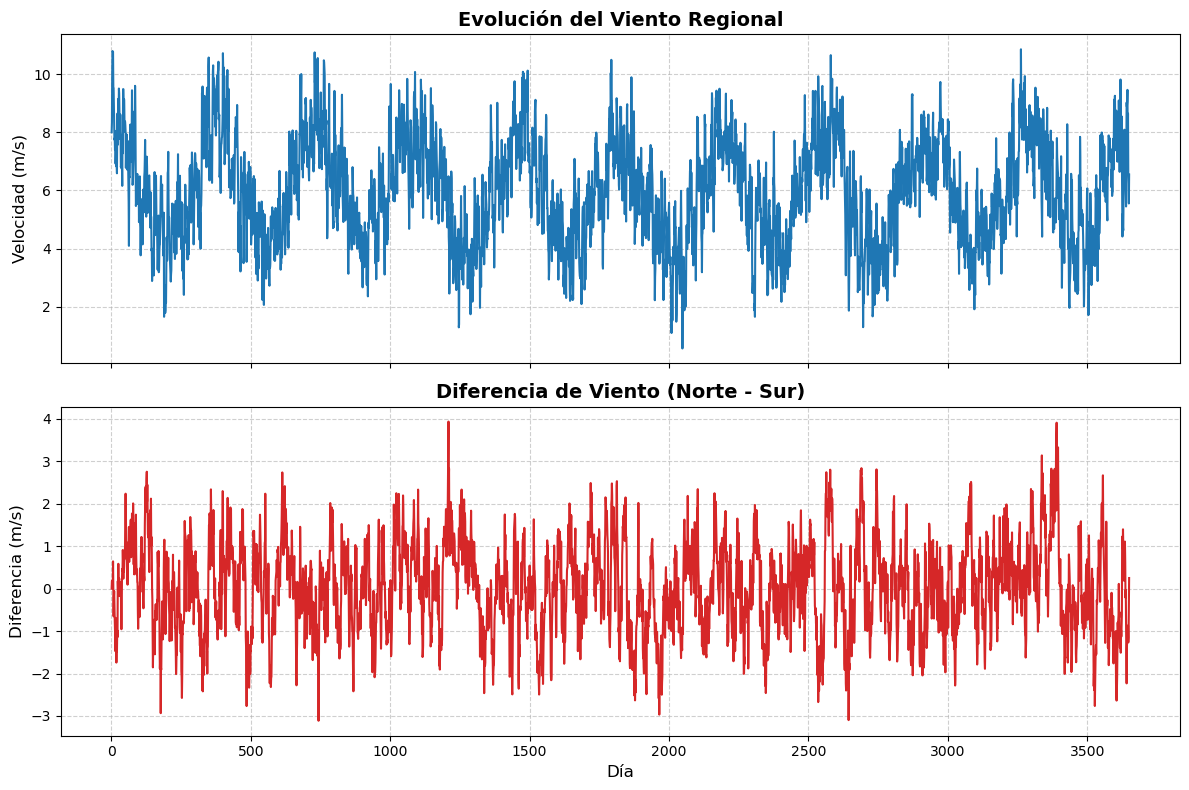

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_excel('Wind data.xlsx')


# 2. Configurar la figura y los subgráficos (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 3. Graficar Viento Regional
ax1.plot(df['dia'], df['regional wind'], color='#1f77b4', linewidth=1.5)
ax1.set_title('Evolución del Viento Regional', fontsize=14, fontweight='bold')
ax1.set_ylabel('Velocidad (m/s)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# 4. Graficar Wind Gap (Diferencia Norte - Sur)
ax2.plot(df['dia'], df['wind gap norte sur'], color='#d62728', linewidth=1.5)
ax2.set_title('Diferencia de Viento (Norte - Sur)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Día', fontsize=12)
ax2.set_ylabel('Diferencia (m/s)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajustar el diseño para que no se superpongan los textos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Ejercico 1, estimacion de parametros

In [5]:
import numpy as np
import statsmodels.api as sm

# 1. Definimos Delta (el paso de tiempo es diario: 1 día sobre 365)
delta = 1 / 365

# 2. Calculamos la media estacional theta(t_i) para el viento regional
df['media_estacional_theta'] = 6 + 2 * np.cos(2 * np.pi * df['dia'] / 365)

# --- PREPARACIÓN DE VARIABLES PARA LA REGRESIÓN ---

# --- A. Viento Regional (S) ---
# Y de la regresión: La diferencia del viento entre hoy y ayer
df['variacion_diaria_S'] = df['regional wind'].diff() 

# X de la regresión: El término que acompaña al parámetro Kappa
df['termino_reversion_S'] = df['media_estacional_theta'] - df['variacion_diaria_S']


# --- B. Diferencia Norte-Sur o Wind Gap (D) ---
# Y de la regresión: La diferencia del 'gap' entre hoy y ayer
df['variacion_diaria_D'] = df['wind gap norte sur'].diff() 

# X de la regresión: El término que acompaña al parámetro Beta
df['termino_reversion_D'] = df['variacion_diaria_D'] * delta


# Al calcular diferencias y valores desfasados (shift), el primer día nos queda vacío (NaN). 
# Lo filtramos para que la regresión no tire error.
df_reg = df.dropna()


# --- REGRESIÓN 1: Viento Regional (estimación de kappa y sigma) ---
# Variable dependiente (Y) vs Variable independiente (X)
modelo_S = sm.OLS(df_reg['variacion_diaria_S'], df_reg['termino_reversion_S'])
resultados_S = modelo_S.fit()

kappa = resultados_S.params['termino_reversion_S']
error_kappa = resultados_S.bse['termino_reversion_S']

# Calculamos sigma a partir de los residuos de la regresión (la volatilidad del error)
residuos_S = resultados_S.resid
sigma = residuos_S.std()

# El error estándar de una desviación estándar muestral se aproxima así:
error_sigma = sigma / np.sqrt(2 * len(residuos_S)) 


# --- REGRESIÓN 2: Wind Gap (estimación de beta y gamma) ---
modelo_D = sm.OLS(df_reg['variacion_diaria_D'], df_reg['termino_reversion_D'])
resultados_D = modelo_D.fit()

beta = resultados_D.params['termino_reversion_D']
error_beta = resultados_D.bse['termino_reversion_D']

residuos_D = resultados_D.resid
gamma = residuos_D.std()
error_gamma = gamma / np.sqrt(2 * len(residuos_D))


# --- IMPRIMIR RESULTADOS ---
print("--- ESTIMACIÓN DE PARÁMETROS ---")
print(f"κ (Kappa): {kappa:.4f} ± {error_kappa:.4f}")
print(f"σ (Sigma): {sigma:.4f} ± {error_sigma:.4f}")
print(f"β (Beta):  {beta:.4f} ± {error_beta:.4f}")
print(f"γ (Gamma): {gamma:.4f} ± {error_gamma:.4f}")

--- ESTIMACIÓN DE PARÁMETROS ---
κ (Kappa): -0.0214 ± 0.0024
σ (Sigma): 0.8922 ± 0.0104
β (Beta):  365.0000 ± 0.0000
γ (Gamma): 0.0000 ± 0.0000


Ejercicio 2. Simular vientos

In [6]:
def simular_vientos(kappa, sigma, beta, gamma, S0, D0, dias):
    """
    Simula los caminos diarios del viento regional y la diferencia entre molinos.
    Devuelve los vectores simulados para S, D, Norte y Sur.
    """
 
    return S_sim, D_sim, Nor_sim, Sur_sim

# --- EJECUCIÓN Y PREPARACIÓN DE DATOS ---

# 1. Definimos la cantidad de días (1 año)
dias_anio = 365

# 2. Filtramos el último año de los datos reales
df_ultimo_anio = df.tail(dias_anio).copy()
# Creamos un eje X común del 1 al 365 para superponer las líneas
eje_x = np.arange(1, dias_anio + 1)

# 3. Simulamos 1 año
# Tomamos como punto de partida el primer dato de ese último año real
S0_anio = df_ultimo_anio['regional wind'].iloc[0]
D0_anio = df_ultimo_anio['wind gap norte sur'].iloc[0]


S_sim_anio, D_sim_anio, N_sim_anio, Sur_sim_anio = simular_vientos(kappa, sigma, beta, gamma, S0_anio, D0_anio, dias_anio)

# Recalculamos el norte real para ese último año
norte_real_anio = df_ultimo_anio['regional wind'] + df_ultimo_anio['wind gap norte sur'] / 2

# --- GRÁFICOS (Último Año Real vs 1 Año Simulado) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1) Viento promedio (Regional)
ax1.plot(eje_x, df_ultimo_anio['regional wind'], label='Real (Último Año)', color='black', alpha=0.7)
ax1.plot(eje_x, S_sim_anio, label='Simulado (1 Año)', color='#1f77b4', alpha=0.8, linewidth=1.5)
ax1.set_title('1. Viento Promedio Regional (S) - 1 Año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Velocidad (m/s)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 2) Diferencia de viento (Wind Gap)
ax2.plot(eje_x, df_ultimo_anio['wind gap norte sur'], label='Real (Último Año)', color='black', alpha=0.7)
ax2.plot(eje_x, D_sim_anio, label='Simulado (1 Año)', color='#d62728', alpha=0.8, linewidth=1.5)
ax2.set_title('2. Diferencia de Viento Norte - Sur (D) - 1 Año', fontsize=13, fontweight='bold')
ax2.set_ylabel('Diferencia (m/s)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# 3) Viento Molino Norte
ax3.plot(eje_x, norte_real_anio, label='Real (Último Año)', color='black', alpha=0.7)
ax3.plot(eje_x, N_sim_anio, label='Simulado (1 Año)', color='#2ca02c', alpha=0.8, linewidth=1.5)
ax3.set_title('3. Viento en Molino Norte - 1 Año', fontsize=13, fontweight='bold')
ax3.set_xlabel('Días del Año')
ax3.set_ylabel('Velocidad (m/s)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

NameError: name 'S_sim' is not defined

Ejercicio 3

In [ ]:
import numpy as np

def ganancia(viento_simulado, umbral, delta):
    n = len(viento_simulado)
    
    # Listas vacías para no desfasar los índices
    vector_ganancia = []
    vector_estados = []
    vector_buen_estado = []
    vector_van = []
    
    estado_anterior = False # Asumimos que el molino arranca apagado
    van_acumulado = 0
    
    for i in range(n):
        viento = viento_simulado[i]      
        
        # 1. Definir si lo apagamos o prendemos hoy basado en el umbral
        if not estado_anterior and viento < umbral:
            estado_actual = True  # Lo prendo
        elif estado_anterior and viento > umbral: 
            estado_actual = False # Lo apago por protección
        else:
            estado_actual = estado_anterior # Se queda como estaba
            
        # 2. Calcular probabilidad de rotura (solo aplica si venía prendido)
        p_rotura = ...
        unif = np.random.uniform(0, 1)
        
        ganancia_hoy = 0
        buen_estado_hoy = True
        
        # 3. Árbol de decisiones y cashflows
        if estado_anterior == True and estado_actual == False:
            # Costo de apagarlo
            
        elif estado_anterior == True and estado_actual == True:
            # Venía prendido y sigue prendido: se expone a romperse
           
                
        elif estado_anterior == False and estado_actual == True:
            # Lo prendo: no cuesta nada y genera plata. 
            # (No se rompe porque la prob es si estaba activo ayer)
            
            
        elif estado_anterior == False and estado_actual == False:
            # Sigue apagado
            

        # 4. Cálculo del VAN con descuento continuo
        dia = i + 1 
        factor_descuento = ...
        ganancia_descontada = ...
        van_acumulado += ganancia_descontada
        
        # 5. Guardar en vectores
        vector_ganancia.append(ganancia_hoy)
        vector_estados.append(estado_actual)
        vector_buen_estado.append(buen_estado_hoy)
        vector_van.append(van_acumulado)
        
        # Actualizar estado para mañana
        estado_anterior = estado_actual

    return van_acumulado, vector_estados, vector_buen_estado, vector_van, vector_ganancia

Ejercico 4

In [ ]:
# Definimos las condiciones iniciales a partir del primer dato real
S0 = df['regional wind'].iloc[0]
D0 = df['wind gap norte sur'].iloc[0]

# 1) Generar los vientos para ambos molinos (Simulamos un camino típico de 1 año)
dias_simulacion = 365
# Usamos la función que creamos en el Punto 2. 
# Asumo que las variables kappa, sigma, beta, gamma, S0 y D0 ya están en memoria.
S_sim, D_sim, viento_norte, viento_sur = simular_vientos(kappa, sigma, beta, gamma, S0, D0, dias_simulacion)


# 2) Correr la función de ganancias para cada molino
umbral_K = 8  # Podés probar cambiar este valor
delta = 1 / 365

# Corremos la lógica para el Molino Norte
van_n, estado_n, roto_n, van_acum_n, vg_n = ganancia(viento_norte, umbral_K, delta)

# Corremos la lógica para el Molino Sur
van_s, estado_s, roto_s, van_acum_s, vg_s = ganancia(viento_sur, umbral_K, delta)


# 3) Graficar para ambos molinos
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
dias = range(dias_simulacion)

# --- PANEL 1: MOLINO NORTE ---
ax1.plot(dias, viento_norte, color='black', alpha=0.6, label='Viento Norte')
ax1.axhline(umbral_K, color='blue', linestyle='--', label=f'Umbral K={umbral_K}')

# Sombreado para días activo y puntos rojos para roturas
ax1.fill_between(dias, 0, max(viento_norte) + 1, where=estado_n, color='green', alpha=0.15, label='Activo')
dias_roto_n = [i for i, buen_estado in enumerate(roto_n) if not buen_estado]
vientos_roto_n = [viento_norte[i] for i in dias_roto_n]
ax1.scatter(dias_roto_n, vientos_roto_n, color='red', s=50, zorder=5, label='Rotura')

ax1.set_title('Molino NORTE: Viento, Estado y Roturas', fontweight='bold', fontsize=12)
ax1.set_ylabel('Velocidad (m/s)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- PANEL 2: MOLINO SUR ---
ax2.plot(dias, viento_sur, color='black', alpha=0.6, label='Viento Sur')
ax2.axhline(umbral_K, color='blue', linestyle='--', label=f'Umbral K={umbral_K}')

# Sombreado para días activo y puntos rojos para roturas
ax2.fill_between(dias, 0, max(viento_sur) + 1, where=estado_s, color='green', alpha=0.15, label='Activo')
dias_roto_s = [i for i, buen_estado in enumerate(roto_s) if not buen_estado]
vientos_roto_s = [viento_sur[i] for i in dias_roto_s]
ax2.scatter(dias_roto_s, vientos_roto_s, color='red', s=50, zorder=5, label='Rotura')

ax2.set_title('Molino SUR: Viento, Estado y Roturas', fontweight='bold', fontsize=12)
ax2.set_ylabel('Velocidad (m/s)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.4)

# --- PANEL 3: VAN ACUMULADO ---
# Sumamos el VAN diario del Norte y del Sur para ver la caja total de la empresa
van_total_empresa = [n + s for n, s in zip(van_acum_n, van_acum_s)]

ax3.plot(dias, van_acum_n, color='#1f77b4', label='VAN Norte')
ax3.plot(dias, van_acum_s, color='#ff7f0e', label='VAN Sur')
ax3.plot(dias, van_total_empresa, color='purple', linewidth=2.5, label='VAN Total (Empresa)')

ax3.set_title('Evolución de los Flujos de Fondos', fontweight='bold', fontsize=12)
ax3.set_xlabel('Días del Año')
ax3.set_ylabel('Dólares ($)')
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Ejercico 5

In [ ]:
import numpy as np

def calcular_van_esperado(N, umbral, kappa, sigma, beta, gamma, S0, D0, dias=365):
    """
    Corre N simulaciones de 1 año para un umbral dado y devuelve 
    el VAN esperado total de la empresa y su error estándar.
    """
     
    ...
    
    return van_esperado, error_estandar

# --- EJECUCIÓN DEL PUNTO 5 ---

# Definimos los hiperparámetros que pediste
N_simulaciones = 1000
umbral_prueba = 10 

# (Asumimos que kappa, sigma, beta, gamma, S0, y D0 ya están cargados de los puntos anteriores)
print(f"Corriendo {N_simulaciones} simulaciones de Montecarlo. Esto puede demorar unos segundos...")

van_promedio, error_van = calcular_van_esperado(
    N=N_simulaciones, 
    umbral=umbral_prueba, 
    kappa=kappa, sigma=sigma, beta=beta, gamma=gamma, S0=S0, D0=D0
)

print("-" * 40)
print(f"RESULTADOS PARA UMBRAL K = {umbral_prueba}")
print(f"VAN Esperado de la Empresa: ${van_promedio:,.2f}")
print(f"Error Estándar: +/- ${error_van:,.2f}")
print("-" * 40)

Ejercicio 6

In [ ]:
# Piensen la mejor forma de hacerlo